# EDA авторынка Пакистана
## Данные
Датасет, для которого производим EDA, можно найти тут: https://www.kaggle.com/datasets/muhamedumarjamil/pakistan-used-cars-dataset
## Цель
Найти признаки влияющие на таргет (в нашем случае цену автомобиля).
## Особенности
В исходном датасете большое разнообразие авто. Мы будем работать с машинами с ДВС на горючем топливе, младше 2000 года выпуска, относительно популярными у местных.  

Представлено 2 ноутбука: **data_cleaning** и **eda**.
В первом производится очистка данных, во втором смотрим на статистики проверяем гипотезы.  

### В этом ноутбуке будет только очистка данных

### Импортируем нужные библиотеки и ознакамливаемся с данными

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Pakistan_Used_Cars.csv')
df

,Unnamed: 0,Car Name,Auction Rating,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR)
0,0,Toyota Aqua 2015 S for Sale,NaN,2015,105000,Hybrid,1500.0,Automatic,cc,4150000.0
1,1,Haval Jolion 2021 1.5T for Sale,NaN,2021,54000,Petrol,1500.0,Automatic,cc,7000000.0
2,2,Suzuki Cultus 2014 EURO II for Sale,NaN,2014,74000,Petrol,1000.0,Manual,cc,1400000.0
3,3,Suzuki Wagon R 2017 VXL for Sale,NaN,2017,89000,Petrol,1000.0,Manual,cc,2375000.0
4,4,Toyota Prado 2011 TZ G 4.0 for Sale,NaN,2011,83000,Petrol,4000.0,Automatic,cc,17800000.0
...,...,...,...,...,...,...,...,...,...,...
78625,78625,Suzuki Wagon R 2018 VXL for Sale,NaN,2018,128000,Petrol,1000.0,Manual,cc,2615000.0
78626,78626,Suzuki Mehran 2014 VXR Euro II for Sale,NaN,2014,26000,Petrol,796.0,Manual,cc,1150000.0
78627,78627,Toyota Yaris Hatchback 2023 X for Sale,NaN,2023,70000,Petrol,1000.0,Automatic,cc,4500000.0
78628,78628,Toyota Corolla 2018 Altis Grande CVT-i 1.8 fo...,NaN,2018,76700,Petrol,1800.0,Automatic,cc,5475000.0


### Откидываем столбец, дублирующий индекс

In [4]:
df = df.iloc[:, 1::]

In [5]:
df

,Car Name,Auction Rating,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR)
0,Toyota Aqua 2015 S for Sale,NaN,2015,105000,Hybrid,1500.0,Automatic,cc,4150000.0
1,Haval Jolion 2021 1.5T for Sale,NaN,2021,54000,Petrol,1500.0,Automatic,cc,7000000.0
2,Suzuki Cultus 2014 EURO II for Sale,NaN,2014,74000,Petrol,1000.0,Manual,cc,1400000.0
3,Suzuki Wagon R 2017 VXL for Sale,NaN,2017,89000,Petrol,1000.0,Manual,cc,2375000.0
4,Toyota Prado 2011 TZ G 4.0 for Sale,NaN,2011,83000,Petrol,4000.0,Automatic,cc,17800000.0
...,...,...,...,...,...,...,...,...,...
78625,Suzuki Wagon R 2018 VXL for Sale,NaN,2018,128000,Petrol,1000.0,Manual,cc,2615000.0
78626,Suzuki Mehran 2014 VXR Euro II for Sale,NaN,2014,26000,Petrol,796.0,Manual,cc,1150000.0
78627,Toyota Yaris Hatchback 2023 X for Sale,NaN,2023,70000,Petrol,1000.0,Automatic,cc,4500000.0
78628,Toyota Corolla 2018 Altis Grande CVT-i 1.8 fo...,NaN,2018,76700,Petrol,1800.0,Automatic,cc,5475000.0


## Смотрим типы столбцов и количество пропусков

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 78630 entries, 0 to 78629
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Car Name         78630 non-null  str    
 1   Auction Rating   4947 non-null   float64
 2   Model Year       78630 non-null  int64  
 3   Mileage          78630 non-null  int64  
 4   Fuel Type        78630 non-null  str    
 5   Engine Capacity  78630 non-null  float64
 6   Transmission     78630 non-null  str    
 7   Engine Unit      78630 non-null  str    
 8   Price (PKR)      77009 non-null  float64
dtypes: float64(3), int64(2), str(4)
memory usage: 5.4 MB


****
## Имеем столбцы:
<b>Car Name</b> - Марка, модель, год, комплектация машины в одном флаконе  
<b>Auction Rating</b> - Рейтинг авто  
<b>Model Year</b> - Год выпуска  
<b>Mileage</b> - Пробег  
<b>Fuel Type</b> - Тип топлива  
<b>Engine Capacity</b> - Объём двигателя  
<b>Transmission</b> - Тип трансмиссии  
<b>Engine Unit</b> - Единица измерения мощности двигателя  
<b>Price (PKR)</b> - Цена в местной валюте (Таргет)
### Также имеем пропуски в столбцах <b>Auction</b> и <b>Price (PKR)</b>
***

### Посмотрим разбросы непрерывных признаков

In [7]:
df.describe()

,Auction Rating,Model Year,Mileage,Engine Capacity,Price (PKR)
count,4947.000000,78630.000000,78630.000000,78630.000000,7.700900e+04
mean,7.993107,2014.587486,97556.015223,1451.489794,5.236257e+06
std,1.650243,8.689690,86997.068344,784.001068,8.340614e+06
min,1.600000,1900.000000,1.000000,0.000000,1.200000e+05
25%,7.000000,2009.000000,43500.000000,1000.000000,1.990000e+06
50%,8.400000,2017.000000,85000.000000,1300.000000,3.400000e+06
75%,9.300000,2021.000000,130000.000000,1800.000000,5.700000e+06
max,10.000000,2026.000000,1000000.000000,15000.000000,9.450000e+08


### Обратим внимание на большой разброс столбцов: <b>Mileage</b>, <b>Engine Capacity</b>, <b>Price (PKR)</b>

### Оценим долю пропусков по столбцам

In [8]:
df.isna().mean().reset_index().sort_values(0, ascending=False)

,index,0
1,Auction Rating,0.937085
8,Price (PKR),0.020616
0,Car Name,0.000000
3,Mileage,0.000000
2,Model Year,0.000000
4,Fuel Type,0.000000
5,Engine Capacity,0.000000
6,Transmission,0.000000
7,Engine Unit,0.000000


93% пропусков в столбце <b>Auction Rating</b>. Столбец мало чем нам сможет помочь при анализе, поэтому смело его удаляем. Также удалим строки с неуказанной ценой автомобиля, т.к. их всего 2% и мы можем исказить данные самостоятельно заполнив таргет

In [9]:
df.shape

(78630, 9)

In [10]:
df = df.drop(columns='Auction Rating')

In [11]:
df = df[df['Price (PKR)'].notna()]

In [12]:
df.shape

(77009, 8)

In [13]:
df.isna().mean().reset_index().sort_values(0, ascending=False)

,index,0
0,Car Name,0.0
1,Model Year,0.0
2,Mileage,0.0
3,Fuel Type,0.0
4,Engine Capacity,0.0
5,Transmission,0.0
6,Engine Unit,0.0
7,Price (PKR),0.0


Удалено примерно 1500 строк, что не так страшно. Посмотрим на дубликаты

In [14]:
df.duplicated().mean()*100

np.float64(16.946071238426676)

In [15]:
df[df.duplicated()]

,Car Name,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR)
46,Suzuki Wagon R 2017 VXL for Sale,2017,80,Petrol,1000.0,Manual,cc,2450000.0
48,Suzuki Wagon R 2017 VXL for Sale,2017,89000,Petrol,1000.0,Manual,cc,2375000.0
49,Toyota Prado 2011 TZ G 4.0 for Sale,2011,83000,Petrol,4000.0,Automatic,cc,17800000.0
56,DFSK Glory 580 2022 Pro for Sale,2022,40000,Petrol,1500.0,Automatic,cc,5300000.0
58,Jaecoo J7 2026 Premium for Sale,2026,12000,PHEV,1500.0,Automatic,cc,10600000.0
...,...,...,...,...,...,...,...,...
78568,Toyota Crown 2002 Royal Saloon G for Sale,2002,99171,Petrol,3000.0,Automatic,cc,4500000.0
78570,Changan Alsvin 2021 1.5L DCT Lumiere for Sale,2021,45000,Petrol,1500.0,Automatic,cc,3550000.0
78571,Lexus RZ 2023 450e Direct 4 for Sale,2023,7300,Electric,71.4,Automatic,kWh,21500000.0
78614,Haval H6 2025 PHEV for Sale,2025,10000,PHEV,1500.0,Automatic,cc,13500000.0


In [16]:
df[df.duplicated(keep=False)]['Car Name'].value_counts(normalize=True)

Car Name
Honda Civic  2021 Oriel 1.8 i-VTEC CVT for Sale    0.011946
Toyota Raize  2020 Z for Sale                      0.010885
Honda Civic  2017 Oriel 1.8 i-VTEC CVT for Sale    0.009864
Honda Civic  2018 Oriel 1.8 i-VTEC CVT for Sale    0.009274
Toyota Raize  2021 Z for Sale                      0.008921
                                                     ...   
Toyota Land Cruiser  2013  for Sale                0.000079
Honda Civic  2009 VTi 1.8 i-VTEC for Sale          0.000079
Toyota Corolla Fielder  2007 X for Sale            0.000079
Nissan Sunny  1986  for Sale                       0.000079
Honda Fit  2016 1.5 Hybrid S Package for Sale      0.000079
Name: proportion, Length: 3530, dtype: float64

Наличие дубликатов может быть объяснено ошибкой при сборе данных. Дубликаты в будущем при обучении модели могут помешать, поэтому удалим их

In [17]:
df = df.drop_duplicates()

In [18]:
df.shape

(63959, 8)

### Признак Model Year

In [19]:
df['Model Year'].describe()

count    63959.000000
mean      2013.696477
std          8.834425
min       1900.000000
25%       2008.000000
50%       2015.000000
75%       2021.000000
max       2026.000000
Name: Model Year, dtype: float64

<Axes: xlabel='Model Year', ylabel='Count'>

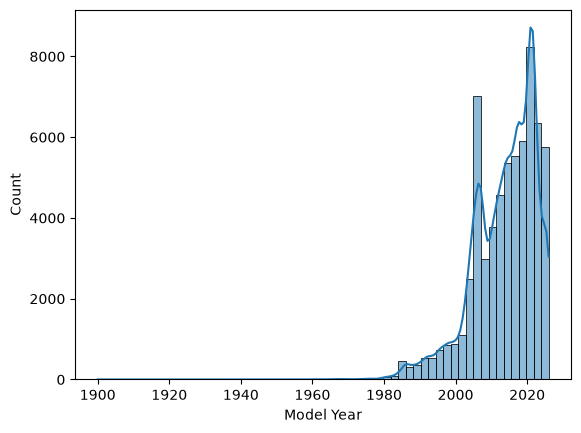

In [20]:
sns.histplot(data=df, x='Model Year', bins=60, kde=True)

Видим левый хвост на гистограмме. Это не ошибка и не выброс для года выпуска автомобиля. Автомобильная  индустрия начала расцветать с 1980 года

### Признак Mileage

In [21]:
df['Mileage'].describe()

count      63959.000000
mean      103941.373317
std        90461.539578
min            1.000000
25%        50000.000000
50%        91000.000000
75%       138300.000000
max      1000000.000000
Name: Mileage, dtype: float64

<Axes: xlabel='Mileage', ylabel='Count'>

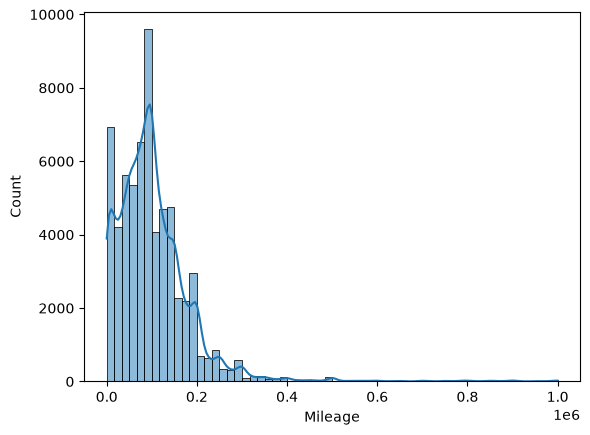

In [22]:
sns.histplot(data=df, x='Mileage', bins=60,kde=True)

Правый хвост также нормален для этого признака, машин миллионников не так много.

### Признак Fuel Type

<Axes: xlabel='Fuel Type', ylabel='count'>

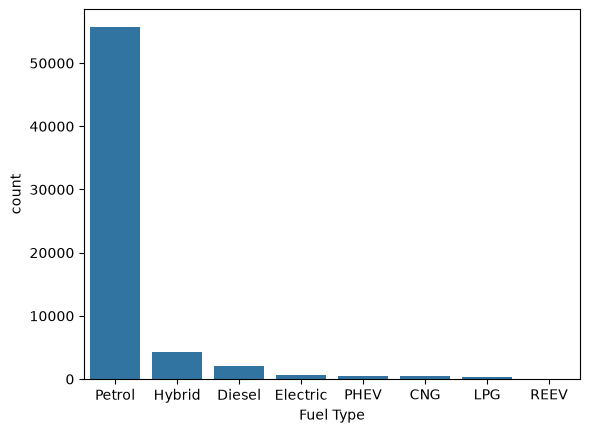

In [23]:
sns.barplot(df['Fuel Type'].value_counts())

<Axes: xlabel='Engine Capacity', ylabel='Count'>

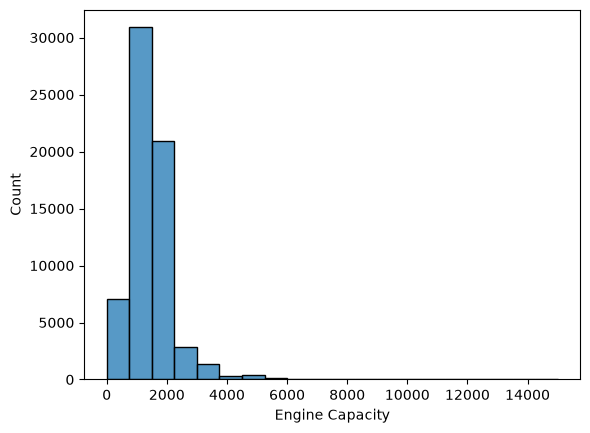

In [24]:
sns.histplot(df['Engine Capacity'], bins=20)

Тут правый хвост интересней, обычно от 10 литров это объём двигателя грузовой машины. Вернёмся к нему позже

### Признак Transmission

<Axes: xlabel='Transmission', ylabel='count'>

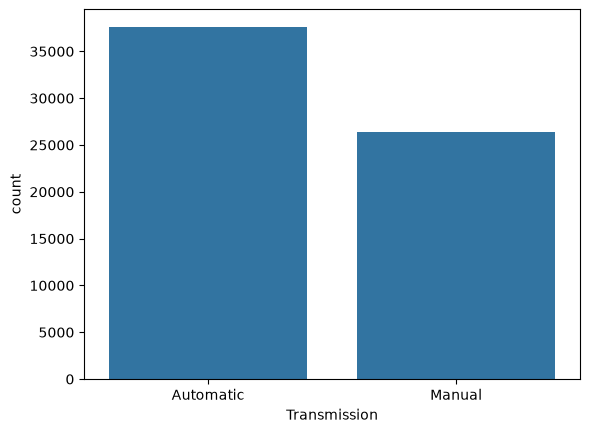

In [25]:
sns.barplot(df['Transmission'].value_counts())

### Признак Engine Unit

<Axes: xlabel='Engine Unit', ylabel='count'>

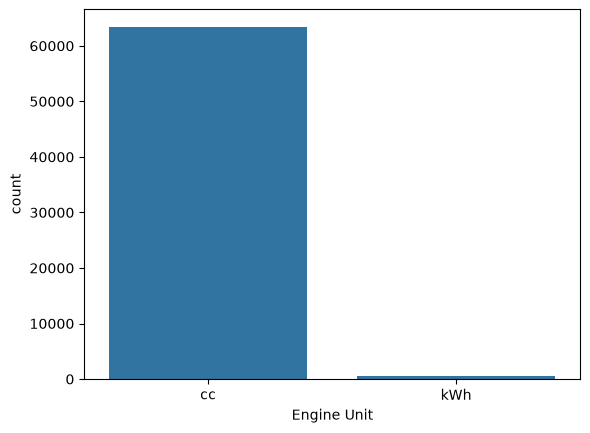

In [26]:
sns.barplot(df['Engine Unit'].value_counts())

Заметим количество электромобилей на рынке меньше

### Признак Price (PKR)

In [27]:
df['Price (PKR)'].describe()

count    6.395900e+04
mean     4.523542e+06
std      7.455008e+06
min      1.200000e+05
25%      1.750000e+06
50%      3.065000e+06
75%      5.070000e+06
max      9.450000e+08
Name: Price (PKR), dtype: float64

<Axes: xlabel='Price (PKR)', ylabel='Count'>

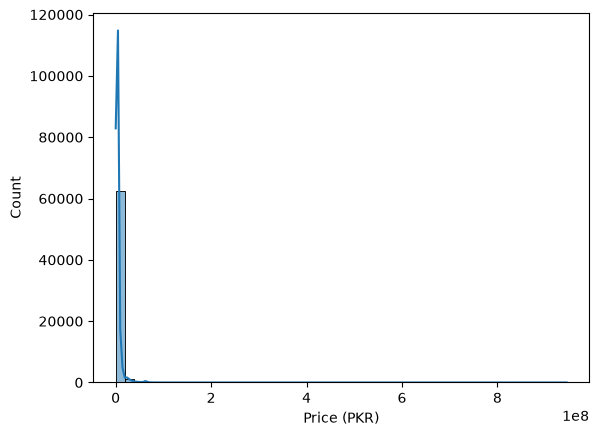

In [28]:
sns.histplot(data=df, x='Price (PKR)', bins=50, kde=True)

Большой правый хвост говорит о большом разбросе цены. Посмотрим на самые дорогие машины

In [29]:
df[df['Price (PKR)'] > df['Price (PKR)'].quantile(0.999)].sort_values('Price (PKR)', ascending=False)

,Car Name,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR)
128,Haval H6 2025 1.5T for Sale,2025,8000,Petrol,1500.0,Automatic,cc,945000000.0
41925,Suzuki Alto 2019 VXL AGS for Sale,2019,105352,Petrol,660.0,Automatic,cc,245000000.0
28238,Range Rover Autobiography 2023 P440e for Sale,2023,10000,PHEV,3000.0,Automatic,cc,175000000.0
49363,Range Rover Autobiography 2022 P440e for Sale,2022,9500,PHEV,3000.0,Automatic,cc,160000000.0
39064,Lexus LX Series 2025 for Sale,2025,800,Hybrid,3500.0,Automatic,cc,155000000.0
28234,Range Rover Autobiography 2022 P440e for Sale,2022,13261,PHEV,3000.0,Automatic,cc,135000000.0
25649,Lexus LX Series 2023 LX 600 Ultra Luxury for ...,2023,300,Petrol,3500.0,Automatic,cc,135000000.0
28236,Range Rover Autobiography 2022 P440e for Sale,2022,17000,PHEV,3000.0,Automatic,cc,135000000.0
28235,Range Rover Autobiography 2022 P440e for Sale,2022,24140,PHEV,3000.0,Automatic,cc,135000000.0
8749,Lexus RX Series 2024 for Sale,2024,121,Petrol,3500.0,Automatic,cc,135000000.0


Haval является самой дорогой машиной, хотя для их марки это слишком большая цена. Скорее всего это ошибка при сборе данных, поэтому разобьём марки машин на 4 категории популярности и 3 ценовых сегмента

In [30]:
df['Brand'] = df['Car Name'].str.split().str[0]

In [31]:
df

,Car Name,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR),Brand
0,Toyota Aqua 2015 S for Sale,2015,105000,Hybrid,1500.0,Automatic,cc,4150000.0,Toyota
1,Haval Jolion 2021 1.5T for Sale,2021,54000,Petrol,1500.0,Automatic,cc,7000000.0,Haval
2,Suzuki Cultus 2014 EURO II for Sale,2014,74000,Petrol,1000.0,Manual,cc,1400000.0,Suzuki
3,Suzuki Wagon R 2017 VXL for Sale,2017,89000,Petrol,1000.0,Manual,cc,2375000.0,Suzuki
4,Toyota Prado 2011 TZ G 4.0 for Sale,2011,83000,Petrol,4000.0,Automatic,cc,17800000.0,Toyota
...,...,...,...,...,...,...,...,...,...
78625,Suzuki Wagon R 2018 VXL for Sale,2018,128000,Petrol,1000.0,Manual,cc,2615000.0,Suzuki
78626,Suzuki Mehran 2014 VXR Euro II for Sale,2014,26000,Petrol,796.0,Manual,cc,1150000.0,Suzuki
78627,Toyota Yaris Hatchback 2023 X for Sale,2023,70000,Petrol,1000.0,Automatic,cc,4500000.0,Toyota
78628,Toyota Corolla 2018 Altis Grande CVT-i 1.8 fo...,2018,76700,Petrol,1800.0,Automatic,cc,5475000.0,Toyota


In [32]:
Brands = df['Brand'].value_counts().reset_index()
Brands.tail(50)

,Brand,count
31,Range,51
32,Jetour,51
33,BAIC,45
34,United,44
35,Ford,41
36,Porsche,34
37,Land,23
38,Isuzu,20
39,Tesla,19
40,MINI,13


In [33]:
top_brends = Brands.sort_values('count', ascending=False).iloc[0:3, 0]
top_brends

0    Toyota
1    Suzuki
2     Honda
Name: Brand, dtype: str

In [34]:
medium_pop_brands = Brands.sort_values('count', ascending=False).iloc[3:12, 0]
medium_pop_brands

3       Daihatsu
4            KIA
5        Hyundai
6         Nissan
7        Changan
8          Haval
9     Mitsubishi
10            MG
11      Mercedes
Name: Brand, dtype: str

In [35]:
low_pop_brands = Brands.sort_values('count', ascending=False).iloc[12:31, 0]

In [36]:
def categorize(x):
    if x in set(top_brends):
        return 3
    if x in set(medium_pop_brands):
        return 2
    if x in set(low_pop_brands):
        return 1
    else:
        return 0
df['Popular degree'] = df['Brand'].map(categorize)
df

,Car Name,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR),Brand,Popular degree
0,Toyota Aqua 2015 S for Sale,2015,105000,Hybrid,1500.0,Automatic,cc,4150000.0,Toyota,3
1,Haval Jolion 2021 1.5T for Sale,2021,54000,Petrol,1500.0,Automatic,cc,7000000.0,Haval,2
2,Suzuki Cultus 2014 EURO II for Sale,2014,74000,Petrol,1000.0,Manual,cc,1400000.0,Suzuki,3
3,Suzuki Wagon R 2017 VXL for Sale,2017,89000,Petrol,1000.0,Manual,cc,2375000.0,Suzuki,3
4,Toyota Prado 2011 TZ G 4.0 for Sale,2011,83000,Petrol,4000.0,Automatic,cc,17800000.0,Toyota,3
...,...,...,...,...,...,...,...,...,...,...
78625,Suzuki Wagon R 2018 VXL for Sale,2018,128000,Petrol,1000.0,Manual,cc,2615000.0,Suzuki,3
78626,Suzuki Mehran 2014 VXR Euro II for Sale,2014,26000,Petrol,796.0,Manual,cc,1150000.0,Suzuki,3
78627,Toyota Yaris Hatchback 2023 X for Sale,2023,70000,Petrol,1000.0,Automatic,cc,4500000.0,Toyota,3
78628,Toyota Corolla 2018 Altis Grande CVT-i 1.8 fo...,2018,76700,Petrol,1800.0,Automatic,cc,5475000.0,Toyota,3


<Axes: xlabel='Popular degree', ylabel='count'>

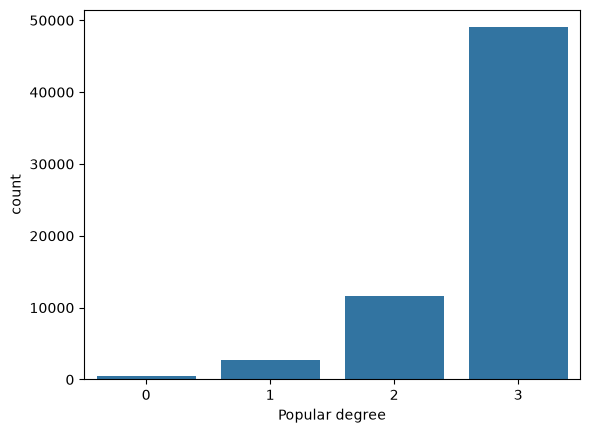

In [37]:
sns.barplot(df['Popular degree'].value_counts())

In [38]:
df['Price category'] = pd.qcut(df['Price (PKR)'], 3, labels=['Low', 'Medium', 'High'])

Посмотрим на разбросы цен в зависимости от популярности марки

<Axes: xlabel='Popular degree', ylabel='Price (PKR)'>

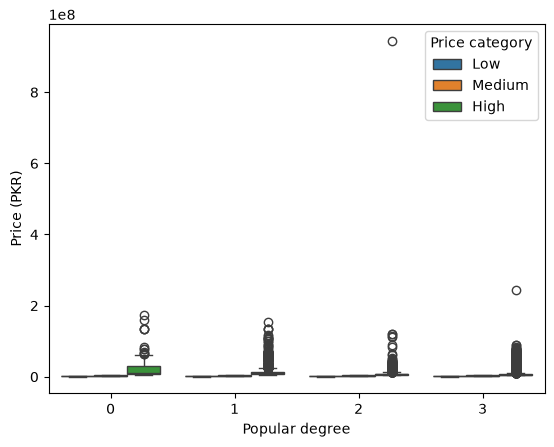

In [39]:
sns.boxplot(df, x='Popular degree', y='Price (PKR)', hue='Price category')
# plt.yscale('log')

Посмотрим на разброс цены марки Haval

<Axes: ylabel='Price (PKR)'>

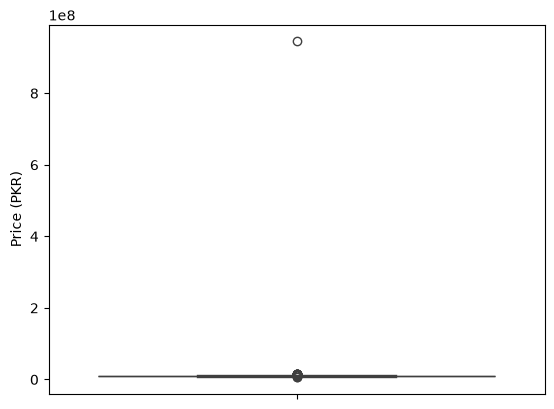

In [40]:
sns.boxplot(df[df['Brand'] == 'Haval'], y='Price (PKR)')

Такие выбросы скорее всего ошибка при сборе данных, поэтому удалим значения которые переходят 99% квартиль

In [77]:
brand_q90 = df.groupby('Brand')['Price (PKR)'].transform(lambda x: x.quantile(0.99))
brand_q90

0        52500000.0
1        13900000.0
2         4850000.0
3         4850000.0
4        52500000.0
            ...    
78625     4850000.0
78626     4850000.0
78627    52500000.0
78628    52500000.0
78629     4850000.0
Name: Price (PKR), Length: 63959, dtype: float64

In [78]:
is_outlier = (df['Price (PKR)'] > brand_q90)
df_clean = df[~is_outlier]

In [79]:
df.shape

(63959, 11)

In [80]:
df_clean.shape

(63300, 11)

<Axes: xlabel='Popular degree', ylabel='Price (PKR)'>

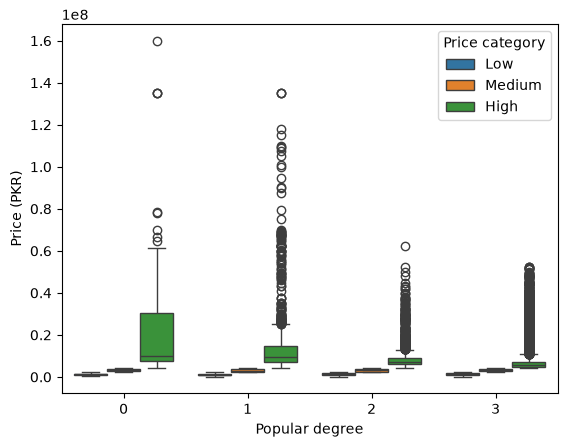

In [81]:
sns.boxplot(df_clean, x='Popular degree', y='Price (PKR)', hue='Price category')


Заметим, что некоторые выбросы остались для <b>Popular degree</b> равной 2 и 3 некритичные, а в 0 и 1 можно их объяснить редкостью модели

Спарсим комплектации автомобилей

In [82]:
df_clean['Car Name'] = df_clean['Car Name'].str.replace(' for Sale', '', regex=False)
df_clean

,Car Name,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR),Brand,Popular degree,Price category
0,Toyota Aqua 2015 S,2015,105000,Hybrid,1500.0,Automatic,cc,4150000.0,Toyota,3,Medium
1,Haval Jolion 2021 1.5T,2021,54000,Petrol,1500.0,Automatic,cc,7000000.0,Haval,2,High
2,Suzuki Cultus 2014 EURO II,2014,74000,Petrol,1000.0,Manual,cc,1400000.0,Suzuki,3,Low
3,Suzuki Wagon R 2017 VXL,2017,89000,Petrol,1000.0,Manual,cc,2375000.0,Suzuki,3,Medium
4,Toyota Prado 2011 TZ G 4.0,2011,83000,Petrol,4000.0,Automatic,cc,17800000.0,Toyota,3,High
...,...,...,...,...,...,...,...,...,...,...,...
78625,Suzuki Wagon R 2018 VXL,2018,128000,Petrol,1000.0,Manual,cc,2615000.0,Suzuki,3,Medium
78626,Suzuki Mehran 2014 VXR Euro II,2014,26000,Petrol,796.0,Manual,cc,1150000.0,Suzuki,3,Low
78627,Toyota Yaris Hatchback 2023 X,2023,70000,Petrol,1000.0,Automatic,cc,4500000.0,Toyota,3,High
78628,Toyota Corolla 2018 Altis Grande CVT-i 1.8,2018,76700,Petrol,1800.0,Automatic,cc,5475000.0,Toyota,3,High


In [83]:
pattern = r'\b(?P<Year>\d{4})\s+(?P<Trim>.*?)(?:\s+for\s+Sale)?$'
extracted = df_clean['Car Name'].str.extract(pattern)
df_clean['Trim'] = extracted['Trim'].str.strip()
df_clean

,Car Name,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR),Brand,Popular degree,Price category,Trim
0,Toyota Aqua 2015 S,2015,105000,Hybrid,1500.0,Automatic,cc,4150000.0,Toyota,3,Medium,S
1,Haval Jolion 2021 1.5T,2021,54000,Petrol,1500.0,Automatic,cc,7000000.0,Haval,2,High,1.5T
2,Suzuki Cultus 2014 EURO II,2014,74000,Petrol,1000.0,Manual,cc,1400000.0,Suzuki,3,Low,EURO II
3,Suzuki Wagon R 2017 VXL,2017,89000,Petrol,1000.0,Manual,cc,2375000.0,Suzuki,3,Medium,VXL
4,Toyota Prado 2011 TZ G 4.0,2011,83000,Petrol,4000.0,Automatic,cc,17800000.0,Toyota,3,High,TZ G 4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
78625,Suzuki Wagon R 2018 VXL,2018,128000,Petrol,1000.0,Manual,cc,2615000.0,Suzuki,3,Medium,VXL
78626,Suzuki Mehran 2014 VXR Euro II,2014,26000,Petrol,796.0,Manual,cc,1150000.0,Suzuki,3,Low,VXR Euro II
78627,Toyota Yaris Hatchback 2023 X,2023,70000,Petrol,1000.0,Automatic,cc,4500000.0,Toyota,3,High,X
78628,Toyota Corolla 2018 Altis Grande CVT-i 1.8,2018,76700,Petrol,1800.0,Automatic,cc,5475000.0,Toyota,3,High,Altis Grande CVT-i 1.8


In [84]:
df_clean['Trim'].value_counts()

Trim
                        4613
VXR                     4084
Oriel 1.8 i-VTEC CVT    1839
GLi 1.3 VVTi            1562
VXL                     1550
                        ... 
SiR                        1
525d                       1
1.8 RSZ                    1
X250d Progressive          1
i7 eDrive50                1
Name: count, Length: 1367, dtype: int64

In [85]:
(df_clean['Trim'] == '').sum()

np.int64(4613)

In [86]:
df_clean.loc[df_clean['Trim'] == '', 'Trim'] = 'No trim'
df_clean

,Car Name,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR),Brand,Popular degree,Price category,Trim
0,Toyota Aqua 2015 S,2015,105000,Hybrid,1500.0,Automatic,cc,4150000.0,Toyota,3,Medium,S
1,Haval Jolion 2021 1.5T,2021,54000,Petrol,1500.0,Automatic,cc,7000000.0,Haval,2,High,1.5T
2,Suzuki Cultus 2014 EURO II,2014,74000,Petrol,1000.0,Manual,cc,1400000.0,Suzuki,3,Low,EURO II
3,Suzuki Wagon R 2017 VXL,2017,89000,Petrol,1000.0,Manual,cc,2375000.0,Suzuki,3,Medium,VXL
4,Toyota Prado 2011 TZ G 4.0,2011,83000,Petrol,4000.0,Automatic,cc,17800000.0,Toyota,3,High,TZ G 4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
78625,Suzuki Wagon R 2018 VXL,2018,128000,Petrol,1000.0,Manual,cc,2615000.0,Suzuki,3,Medium,VXL
78626,Suzuki Mehran 2014 VXR Euro II,2014,26000,Petrol,796.0,Manual,cc,1150000.0,Suzuki,3,Low,VXR Euro II
78627,Toyota Yaris Hatchback 2023 X,2023,70000,Petrol,1000.0,Automatic,cc,4500000.0,Toyota,3,High,X
78628,Toyota Corolla 2018 Altis Grande CVT-i 1.8,2018,76700,Petrol,1800.0,Automatic,cc,5475000.0,Toyota,3,High,Altis Grande CVT-i 1.8


Вернёмся к признаку <b>Engine Capacity</b>

In [87]:
df_clean['Engine Capacity'].describe()

count    63300.000000
mean      1381.402162
std        705.093402
min          0.000000
25%       1000.000000
50%       1300.000000
75%       1600.000000
max      15000.000000
Name: Engine Capacity, dtype: float64

<Axes: ylabel='Engine Capacity'>

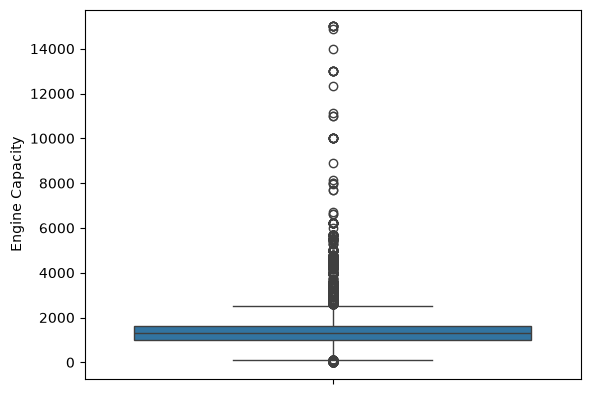

In [88]:
sns.boxplot(df_clean, y='Engine Capacity')

In [104]:
df_clean['Engine Capacity'].quantile(0.99999)

np.float64(7067.03000000125)

In [89]:
df_clean.sort_values('Engine Capacity', ascending=False).head(30)

,Car Name,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR),Brand,Popular degree,Price category,Trim
27021,Toyota Corolla 1980,1980,245000,Petrol,15000.0,Manual,cc,400000.0,Toyota,3,Low,No trim
33945,Toyota Corolla 2008,2008,200000,CNG,15000.0,Automatic,cc,1800000.0,Toyota,3,Low,No trim
59639,Suzuki Bolan 2021,2021,87000,Petrol,15000.0,Manual,cc,2100000.0,Suzuki,3,Low,No trim
43414,Toyota Platz 2008,2008,15000,Petrol,15000.0,Automatic,cc,2300000.0,Toyota,3,Medium,No trim
20229,Honda Civic 2006,2006,138000,Petrol,15000.0,Manual,cc,1450000.0,Honda,3,Low,No trim
74783,Toyota Prius 2015,2015,115000,Hybrid,15000.0,Automatic,cc,3100000.0,Toyota,3,Medium,No trim
42297,Honda Vezel 2015,2015,175000,Petrol,14900.0,Automatic,cc,5200000.0,Honda,3,High,No trim
28178,Suzuki Ravi 2019,2019,14400,Petrol,14000.0,Manual,cc,1460000.0,Suzuki,3,Low,No trim
1624,Honda City 2018,2018,130000,Petrol,13000.0,Automatic,cc,3800000.0,Honda,3,Medium,No trim
41375,Honda Civic 2006,2006,90000,Petrol,13000.0,Manual,cc,1700000.0,Honda,3,Low,No trim


Большой разброс и аномально большие значение у малолитражек - ошибка. Заменим значения большие 85% квартиля по бренду медианой этого бренда

<Axes: ylabel='Engine Capacity'>

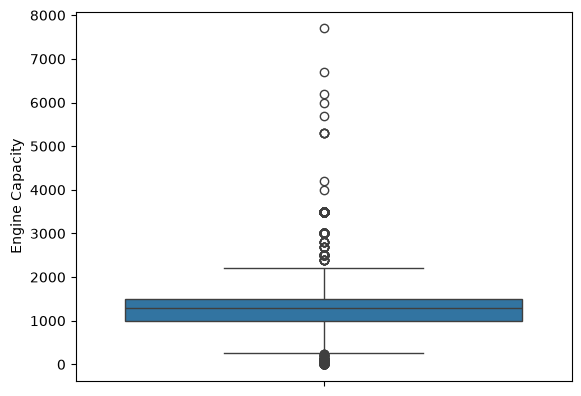

In [105]:
medians = df_clean.groupby('Brand')['Engine Capacity'].transform(lambda x: x.median())
q85 = df_clean['Engine Capacity'].quantile(0.99999)
df_clean['Engine Capacity'] = np.where(df_clean['Engine Capacity'] > q85, medians, df_clean['Engine Capacity'])
sns.boxplot(df_clean, y='Engine Capacity')

In [106]:
df_clean.sort_values('Engine Capacity', ascending=False).head(15)

,Car Name,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR),Brand,Popular degree,Price category,Trim
60079,Hino 500 Series 2014 FG8J 4x2,2014,100000,Diesel,7700.0,Manual,cc,11000000.0,Hino,0,High,FG8J 4x2
4924,Rolls Royce Phantom 1967,1967,60000,Petrol,6700.0,Automatic,cc,30000000.0,Rolls,0,High,No trim
27202,Dodge Ram 2022 1500 TRX,2022,27000,Petrol,6200.0,Automatic,cc,61500000.0,Dodge,0,High,1500 TRX
69541,Hummer H2 2003,2003,60000,Petrol,6000.0,Automatic,cc,17500000.0,Hummer,0,High,No trim
14547,Chrysler 300 C 2006 SRT,2006,192000,Petrol,5700.0,Automatic,cc,11800000.0,Chrysler,0,High,SRT
63658,GMC Sierra 2022,2022,68000,Petrol,5300.0,Automatic,cc,55000000.0,GMC,0,High,No trim
34706,GMC Sierra 2021,2021,77000,Petrol,5300.0,Automatic,cc,39000000.0,GMC,0,High,No trim
69191,GMC Sierra 2016 Denali,2016,60000,Petrol,5300.0,Automatic,cc,18500000.0,GMC,0,High,Denali
36664,GMC Sierra 2019 Denali,2019,54000,Petrol,5300.0,Automatic,cc,34900000.0,GMC,0,High,Denali
6419,Jaguar XF 2009 4.2 Supercharged V8,2009,125,Petrol,4200.0,Automatic,cc,8000000.0,Jaguar,0,High,4.2 Supercharged V8


Большой литраж остался у внедорожников, значит очистка произошла успешно.

In [107]:
df_clean.sort_values('Engine Capacity', ).head(15)

,Car Name,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR),Brand,Popular degree,Price category,Trim
36817,Deepal S05 2026,2026,20,Electric,1.00,Automatic,kWh,10800000.0,Deepal,1,High,No trim
22279,Deepal S05 2026 REEV Premium,2026,70,PHEV,3.00,Automatic,kWh,10700000.0,Deepal,1,High,REEV Premium
2804,Toyota C+pod 2022 G,2022,8000,Electric,9.00,Automatic,kWh,2800000.0,Toyota,3,Medium,G
2183,Lexus RX Series 2023,2023,25000,Electric,10.00,Automatic,kWh,23500000.0,Lexus,1,High,No trim
7343,Alektra Metro 2026 4-Door (10.8 kWh),2026,270,Electric,10.80,Automatic,kWh,1350000.0,Alektra,0,Low,4-Door (10.8 kWh)
48123,Alektra Metro 2026 4-Door (12.96 kWh),2026,170,Electric,12.96,Automatic,kWh,1550000.0,Alektra,0,Low,4-Door (12.96 kWh)
18697,Alektra Metro 2026 Solar 4-Door (12.96 kWh),2026,5000,Electric,12.96,Automatic,kWh,1400000.0,Alektra,0,Low,Solar 4-Door (12.96 kWh)
18356,Alektra Metro 2026 4-Door (12.96 kWh),2026,200,Electric,13.00,Automatic,kWh,1450000.0,Alektra,0,Low,4-Door (12.96 kWh)
57182,GUGO GIGI 2024 220,2024,40000,Electric,16.00,Automatic,kWh,2950000.0,GUGO,0,Medium,220
50219,GUGO GIGI 2025 220,2025,11200,Electric,16.00,Automatic,kWh,3350000.0,GUGO,0,Medium,220


Видим нулевые значения у ДВС с горючим топливом, что ошибка. Удалим эти строки

In [108]:
df_clean = df_clean[df_clean['Engine Capacity'] != 0]

Сохраним очищенный датасет

In [109]:
df_clean.to_csv('Pakistan_Used_Cars_Clean.csv')